## 0. Excel Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../analysis/excel/04_transpose_removal/04_transpose_removal.xlsx"

df = pd.read_excel(file_path, sheet_name="Master Table")
df["Block"] = df["Block"].ffill()

print(df.head(10))

  Block   #          종류    H    W      S   IC   OC  MAC Count  Memory Traffic  \
0     1   1  Project PW  112  112  12544   32   16    6422528         2410496   
1     2   2   Expand PW  112  112  12544   16   96   19267584         5625856   
2     2   3  Project PW   56   56   3136   96   24    7225344         1514496   
3     2   4   Expand PW   56   56   3136   24  144   10838016         2121216   
4     2   5  Project PW   56   56   3136  144   24   10838016         2121216   
5     3   6   Expand PW   56   56   3136   24  144   10838016         2121216   
6     3   7  Project PW   28   28    784  144   32    3612672          570368   
7     3   8   Expand PW   28   28    784   32  192    4816896          727040   
8     3   9  Project PW   28   28    784  192   32    4816896          727040   
9     3  10   Expand PW   28   28    784   32  192    4816896          727040   

   ...  WSRAM DMA (s)  PSRAM DMA (s)  Host Run time (s)  Numpy Layout (s)  \
0  ...       0.000020       0.0

In [3]:
df.columns

Index(['Block', '#', '종류', 'H', 'W', 'S', 'IC', 'OC', 'MAC Count',
       'Memory Traffic', 'Arithmetic Intensity', 'Speedup (End-to-End)',
       'BandWidth (GB/s)', 'Repeat', 'Repeat_x_MAC', 'tile_S', 'tile_IC',
       'tile_OC', 'Theoretical Peak MAC/s', 'Input SRAM Depth (<=30000)',
       'Psum SRAM Depth (<= 15000)', 'Weight SRAM Depth (<= 30000)',
       'CPU reference time(s)', 'FPGA End-to-End time(s)',
       'CPU Throughput (MB/s)', 'FPGA End-to-End Throughpout (MB/s)',
       'Utilization (%)', 'PL Active time (s)', 'Run time(PL) (s)',
       'DMA time (s)', 'Control time (s)', 'RUN (%)', 'RUN (E2E 기준) (%)',
       'DMA (%)', 'ISRAM DMA (s)', 'WSRAM DMA (s)', 'PSRAM DMA (s)',
       'Host Run time (s)', 'Numpy Layout (s)', 'MMIO (s)',
       'DMA Send wait (s)', 'DMA Recv Wait (s)', 'Numpy (%)', 'MMIO (%)',
       'DMA Wait (%)'],
      dtype='object')

## 1. Correlation

### 1.1 AI vs Speedup

In [6]:
df["Arithmetic Intensity"].corr(df["Speedup (End-to-End)"])

0.761098636194374

In [7]:
df["BandWidth (GB/s)"].corr(df["Speedup (End-to-End)"])

0.48723819896264864

In [ ]:
df["AI_x_BW"] = df["Arithmetic Intensity"] * df["BandWidth (GB/s)"]
df["AI_x_BW"].corr(df["Speedup (End-to-End)"])

0.8302217306257182

In [10]:
df[[
    "Arithmetic Intensity",
    "BandWidth (GB/s)",
    "AI_x_BW",
    "Speedup (End-to-End)"
]].corr()

,Arithmetic Intensity,BandWidth (GB/s),AI_x_BW,Speedup (End-to-End)
Arithmetic Intensity,1.000000,0.115055,0.676477,0.761099
BandWidth (GB/s),0.115055,1.000000,0.770663,0.487238
AI_x_BW,0.676477,0.770663,1.000000,0.830222
Speedup (End-to-End),0.761099,0.487238,0.830222,1.000000


In [11]:
df["Repeat"].corr(df["BandWidth (GB/s)"])

-0.4302963977406603

In [12]:
df["tile_S"].corr(df["BandWidth (GB/s)"])

0.035281011525357134

In [ ]:
df["Repeat"].corr(df["Speedup (End-to-End)"])

-0.38735447410577817

### 1.2 Scatter Plot

In [3]:
df["AI_x_BW"] = df["Arithmetic Intensity"] * df["BandWidth (GB/s)"]

In [4]:
y = df["Speedup (End-to-End)"]

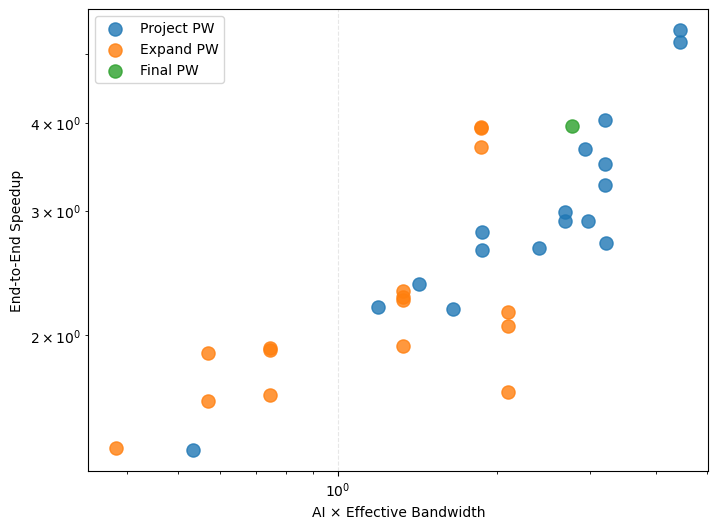

In [9]:
import matplotlib.pyplot as plt
import numpy as np


colors = {
    "Expand PW": "#1f77b4",
    "Depthwise": "#ff7f0e",
    "Project PW": "#2ca02c"
}

plt.figure(figsize=(8,6))

for kind in df["종류"].unique():
    subset = df[df["종류"] == kind]
    plt.scatter(
        subset["AI_x_BW"],
        subset["Speedup (End-to-End)"],
        label=kind,
        s=90,
        alpha=0.8
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("AI × Effective Bandwidth")
plt.ylabel("End-to-End Speedup")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 2. Speedup Plot

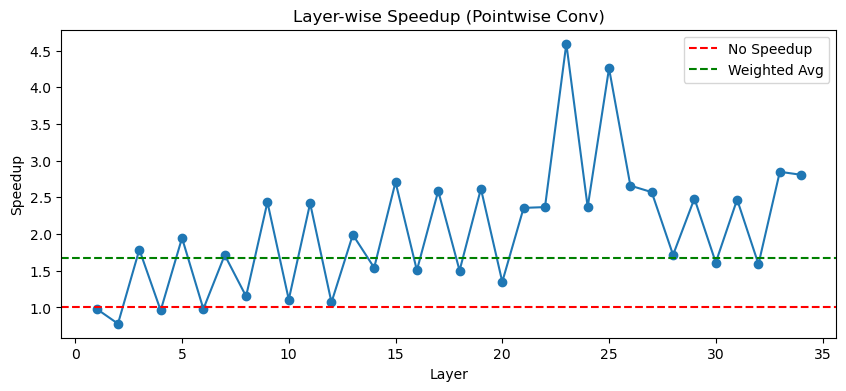

In [12]:
import matplotlib.pyplot as plt
import pandas as pd


plt.figure(figsize=(10,4))
plt.plot(df["#"], df["Speedup"], marker='o')
plt.axhline(1.0, linestyle='--', color='red', label='No Speedup')
plt.axhline(1.67, linestyle='--', color='green', label='Weighted Avg')
plt.xlabel("Layer")
plt.ylabel("Speedup")
plt.title("Layer-wise Speedup (Pointwise Conv)")
plt.legend()
plt.show()

## 3. Time Breakdown Plot

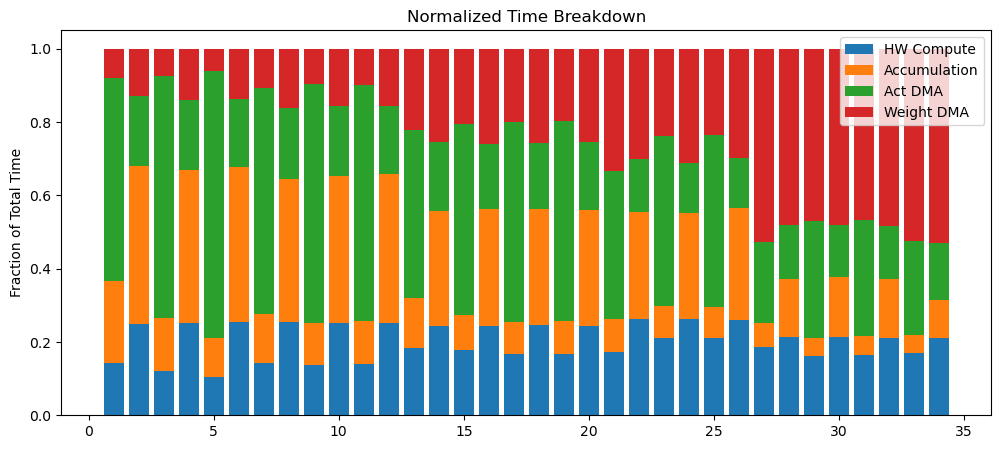

In [3]:
total_time = (
    df["Activation DMA time(s)"] +
    df["Weight DMA time(s)"] +
    df["Pure HW compute time(s)"] +
    df["Accumulation Time(s)"]
)

plt.figure(figsize=(12,5))

# 1️⃣ HW Compute (맨 아래)
plt.bar(df["#"], df["Pure HW compute time(s)"]/total_time,
        label="HW Compute")

bottom1 = df["Pure HW compute time(s)"]/total_time

# 2️⃣ Accumulation
plt.bar(df["#"], df["Accumulation Time(s)"]/total_time,
        bottom=bottom1,
        label="Accumulation")

bottom2 = bottom1 + df["Accumulation Time(s)"]/total_time

# 3️⃣ Activation DMA
plt.bar(df["#"], df["Activation DMA time(s)"]/total_time,
        bottom=bottom2,
        label="Act DMA")

bottom3 = bottom2 + df["Activation DMA time(s)"]/total_time

# 4️⃣ Weight DMA (맨 위)
plt.bar(df["#"], df["Weight DMA time(s)"]/total_time,
        bottom=bottom3,
        label="Weight DMA")

plt.ylabel("Fraction of Total Time")
plt.title("Normalized Time Breakdown")
plt.legend()
plt.show()


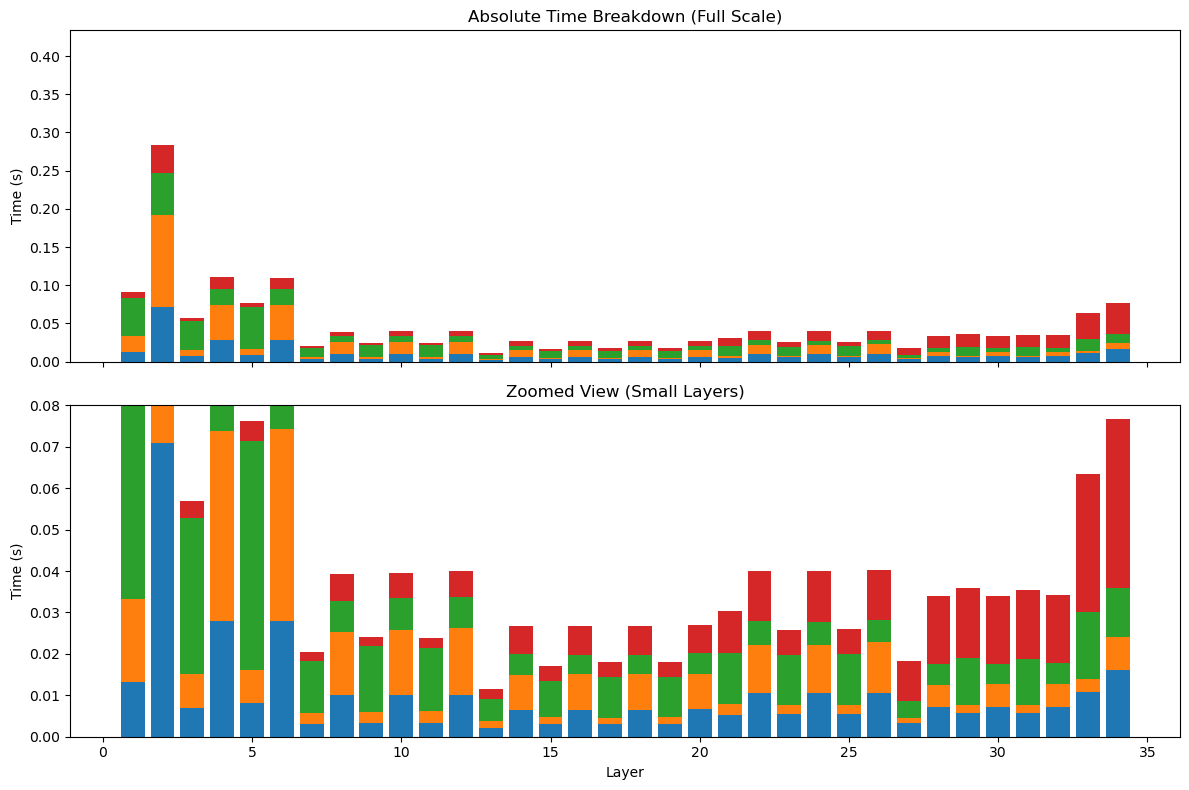

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12,8))

# ===== 위쪽 (전체 스케일) =====
ax1.bar(df["#"], df["Pure HW compute time(s)"], label="HW Compute")

bottom1 = df["Pure HW compute time(s)"]
ax1.bar(df["#"], df["Accumulation Time(s)"], bottom=bottom1)

bottom2 = bottom1 + df["Accumulation Time(s)"]
ax1.bar(df["#"], df["Activation DMA time(s)"], bottom=bottom2)

bottom3 = bottom2 + df["Activation DMA time(s)"]
ax1.bar(df["#"], df["Weight DMA time(s)"], bottom=bottom3)

ax1.set_ylabel("Time (s)")
ax1.set_title("Absolute Time Breakdown (Full Scale)")
ax1.set_ylim(0, df["FPGA End-to-End time(s)"].max()*1.1)


# ===== 아래쪽 (작은 값 확대) =====
ax2.bar(df["#"], df["Pure HW compute time(s)"])

bottom1 = df["Pure HW compute time(s)"]
ax2.bar(df["#"], df["Accumulation Time(s)"], bottom=bottom1)

bottom2 = bottom1 + df["Accumulation Time(s)"]
ax2.bar(df["#"], df["Activation DMA time(s)"], bottom=bottom2)

bottom3 = bottom2 + df["Activation DMA time(s)"]
ax2.bar(df["#"], df["Weight DMA time(s)"], bottom=bottom3)

ax2.set_ylim(0, 0.08)   # 🔥 여기서 확대 구간 조절
ax2.set_xlabel("Layer")
ax2.set_ylabel("Time (s)")
ax2.set_title("Zoomed View (Small Layers)")

plt.tight_layout()
plt.show()


## 4. Throughput Plot

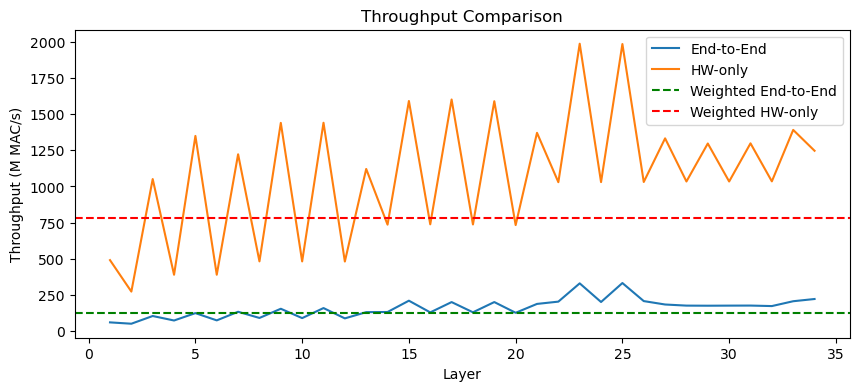

In [6]:
df["Throughput"] = df["MAC 수"] / df["FPGA End-to-End time(s)"]
df["HW_Throughput"] = df["MAC 수"] / df["Pure HW compute time(s)"]

weighted_throughput = df["MAC 수"].sum() / df["FPGA End-to-End time(s)"].sum()
weighted_hw_throughput = df["MAC 수"].sum() / df["Pure HW compute time(s)"].sum()

plt.figure(figsize=(10,4))
plt.plot(df["#"], df["Throughput"]/1e6, label="End-to-End")
plt.plot(df["#"], df["HW_Throughput"]/1e6, label="HW-only")

plt.axhline(weighted_throughput/1e6, 
            linestyle='--', 
            color='green', 
            label="Weighted End-to-End")

plt.axhline(weighted_hw_throughput/1e6, 
            linestyle='--', 
            color='red', 
            label="Weighted HW-only")

plt.xlabel("Layer")
plt.ylabel("Throughput (M MAC/s)")
plt.title("Throughput Comparison")
plt.legend()
plt.show()

## 5. Utilization

In [7]:
peak_mac = 8 * 4 * 100e6   # 3.2G

df["Utilization"] = df["HW_Throughput"] / peak_mac

expand_df = df[df["종류"].str.contains("Expand")]
project_df = df[df["종류"].str.contains("Project")]

expand_avg = expand_df["Utilization"].mean()
project_avg = project_df["Utilization"].mean()

print("Expand Avg Utilization:", expand_avg * 100, "%")
print("Project Avg Utilization:", project_avg * 100, "%")

Expand Avg Utilization: 22.705830207950136 %
Project Avg Utilization: 43.32930217481493 %


In [8]:
expand_weighted_hw = (
    expand_df["MAC 수"].sum() /
    expand_df["Pure HW compute time(s)"].sum()
)

project_weighted_hw = (
    project_df["MAC 수"].sum() /
    project_df["Pure HW compute time(s)"].sum()
)

total_weighted_hw = (
    df["MAC 수"].sum() /
    df["Pure HW compute time(s)"].sum()
)

expand_weighted_util = expand_weighted_hw / peak_mac
project_weighted_util = project_weighted_hw / peak_mac
total_weighted_util = total_weighted_hw / peak_mac

print("Expand Weighted Utilization:",
      expand_weighted_util * 100, "%")

print("Project Weighted Utilization:",
      project_weighted_util * 100, "%")

print("Overall Weighted Utilization:",
      total_weighted_util * 100, "%")

Expand Weighted Utilization: 17.147627364494834 %
Project Weighted Utilization: 40.633120135624566 %
Overall Weighted Utilization: 24.383206609259837 %


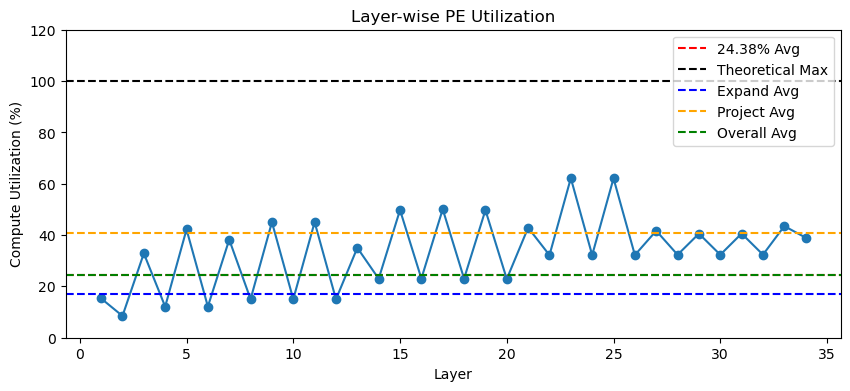

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(df["#"], df["Utilization"] * 100, marker='o')

plt.axhline(24.38, linestyle='--', color='red', label="24.38% Avg")
plt.axhline(100, linestyle='--', color='black', label="Theoretical Max")

plt.axhline(expand_weighted_util*100,
            linestyle='--', color='blue',
            label="Expand Avg")

plt.axhline(project_weighted_util*100,
            linestyle='--', color='orange',
            label="Project Avg")

plt.axhline(total_weighted_util*100,
            linestyle='--', color='green',
            label="Overall Avg")


plt.xlabel("Layer")
plt.ylabel("Compute Utilization (%)")
plt.title("Layer-wise PE Utilization")
plt.legend()
plt.ylim(0, 120)
plt.show()


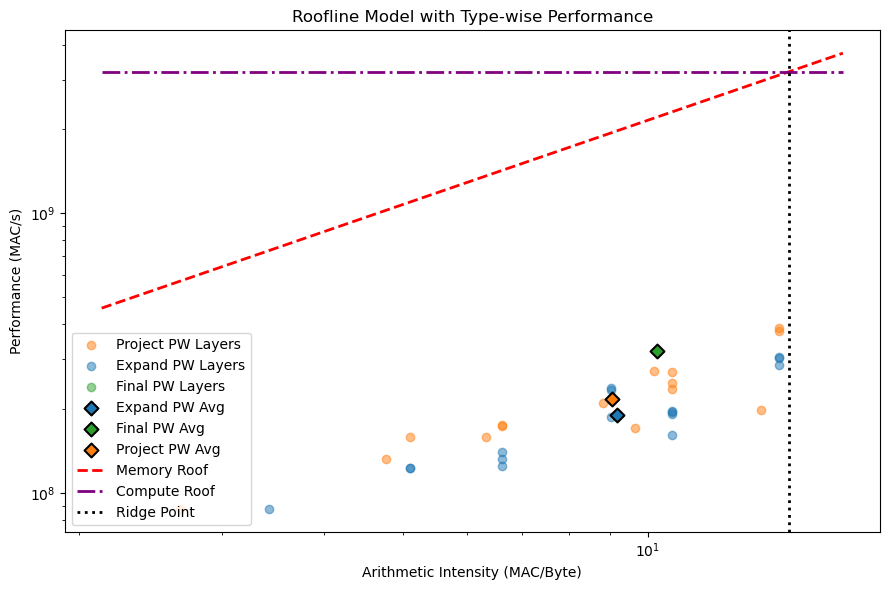

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Precompute performance
# =========================

df["Achieved Perf (MAC/s)"] = df["MAC Count"] / df["FPGA End-to-End time(s)"]

peak_compute = df["Theoretical Peak MAC/s"].iloc[0]
effective_bw = df["BandWidth (GB/s)"].mean() * 1e9

# =========================
# Type colors
# =========================

colors = {
    "Expand PW": "tab:blue",
    "Project PW": "tab:orange",
    "Final PW": "tab:green"
}

# =========================
# Plot
# =========================

plt.figure(figsize=(9,6))

# Layer-wise scatter by type
for t in df["종류"].unique():
    subset = df[df["종류"] == t]
    plt.scatter(
        subset["Arithmetic Intensity"],
        subset["Achieved Perf (MAC/s)"],
        alpha=0.5,
        label=f"{t} Layers",
        color=colors.get(t, "gray")
    )

# =========================
# Type-wise average points
# =========================

grouped = df.groupby("종류").agg({
    "Arithmetic Intensity": "mean",
    "Achieved Perf (MAC/s)": "mean"
}).reset_index()

for i in range(len(grouped)):
    t = grouped["종류"][i]
    plt.scatter(
        grouped["Arithmetic Intensity"][i],
        grouped["Achieved Perf (MAC/s)"][i],
        s=50,
        marker='D',
        color=colors.get(t, "black"),
        edgecolors='black',
        linewidths=1.5,
        label=f"{t} Avg"
    )

# =========================
# Roof lines
# =========================

ai_line = np.linspace(
    df["Arithmetic Intensity"].min()*0.8,
    df["Arithmetic Intensity"].max()*1.2,
    200
)

# Memory Roof (빨강)
memory_roof = effective_bw * ai_line
plt.plot(
    ai_line,
    memory_roof,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Memory Roof"
)

# Compute Roof (보라)
compute_roof = np.ones_like(ai_line) * peak_compute
plt.plot(
    ai_line,
    compute_roof,
    linestyle="-.",
    linewidth=2,
    color="purple",
    label="Compute Roof"
)

# Ridge Point (검정 점선)
ridge_ai = peak_compute / effective_bw
plt.axvline(
    ridge_ai,
    linestyle=":",
    linewidth=2,
    color="black",
    label="Ridge Point"
)

# =========================
# Axis
# =========================

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Arithmetic Intensity (MAC/Byte)")
plt.ylabel("Performance (MAC/s)")
plt.title("Roofline Model with Type-wise Performance")

plt.legend()
plt.tight_layout()
plt.show()

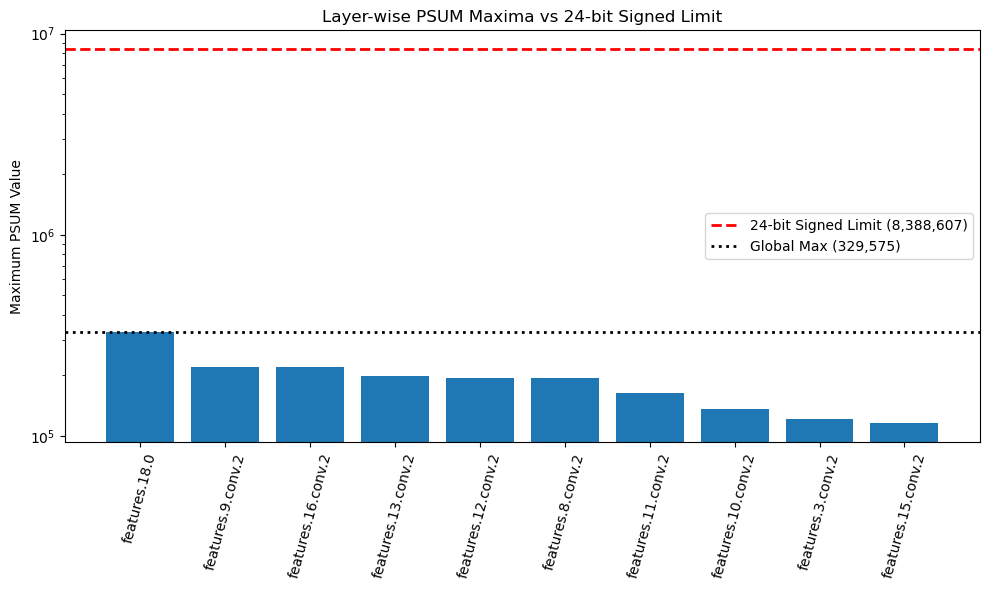

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Layer-wise PSUM Max (직접 입력)
# ==============================

layers = [
    "features.18.0",
    "features.9.conv.2",
    "features.16.conv.2",
    "features.13.conv.2",
    "features.12.conv.2",
    "features.8.conv.2",
    "features.11.conv.2",
    "features.10.conv.2",
    "features.3.conv.2",
    "features.15.conv.2"
]

psum_values = [
    329575,
    220065,
    219144,
    199034,
    193649,
    193294,
    162953,
    135683,
    121708,
    115758
]

limit_24bit = 8388607  # 2^23 - 1

# ==============================
# Plot
# ==============================

plt.figure(figsize=(10,6))

plt.bar(layers, psum_values)

# 24-bit limit line
plt.axhline(
    limit_24bit,
    linestyle="--",
    linewidth=2,
    color="red",
    label="24-bit Signed Limit (8,388,607)"
)

# Global max line
global_max = max(psum_values)
plt.axhline(
    global_max,
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Global Max ({global_max:,})"
)

plt.xticks(rotation=75)
plt.ylabel("Maximum PSUM Value")
plt.title("Layer-wise PSUM Maxima vs 24-bit Signed Limit")
plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()

## 6. Decomposition & Breakdown

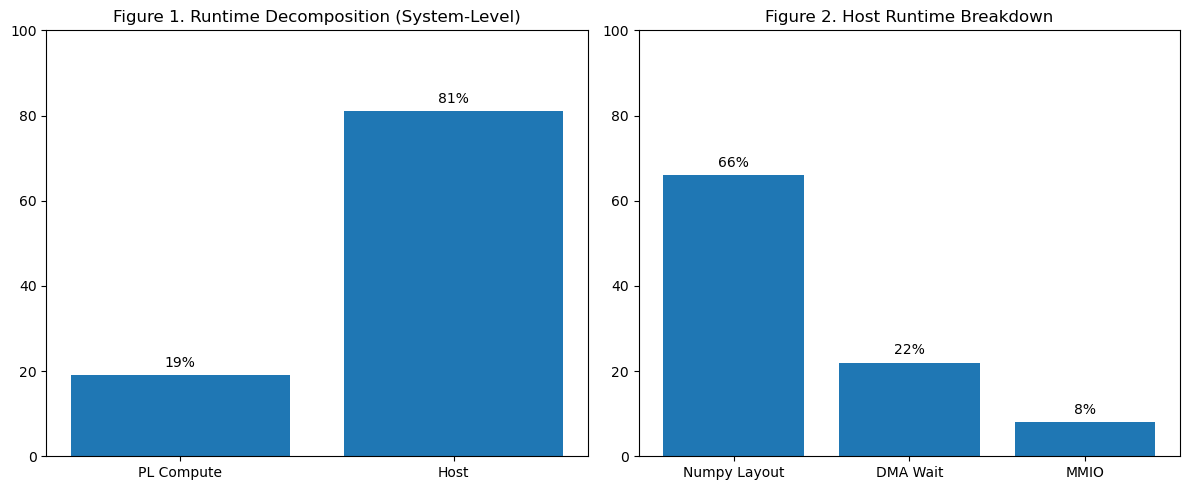

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Figure 1
labels_sys = ["PL Compute", "Host"]
values_sys = [19, 81]
axes[0].bar(labels_sys, values_sys)
axes[0].set_ylim(0,100)
axes[0].set_title("Figure 1. Runtime Decomposition (System-Level)")

for i, v in enumerate(values_sys):
    axes[0].text(i, v + 2, f"{v}%", ha='center')

# Figure 2
labels_host = ["Numpy Layout", "DMA Wait", "MMIO"]
values_host = [66, 22, 8]
axes[1].bar(labels_host, values_host)
axes[1].set_ylim(0,100)
axes[1].set_title("Figure 2. Host Runtime Breakdown")

for i, v in enumerate(values_host):
    axes[1].text(i, v + 2, f"{v}%", ha='center')

plt.tight_layout()
plt.show()